This script is mostly derived from the tutorial scripts. It imports and reduces a phantom model, saving the result in a seperate directory.

In [1]:
import magritte.setup as setup                # Model setup
import magritte.core  as magritte             # Core functionality
import magritte.mesher as mesher              # Model remeshing
import numpy          as np                   # Data structures
import warnings                               # Hide warnings
warnings.filterwarnings('ignore')             # especially for yt
import yt                                     # 3D plotting
import os
import plons

from tqdm          import tqdm                # Progress bars
from astropy       import constants, units    # Unit conversions
from scipy.spatial import Delaunay, cKDTree   # Finding neighbors
from yt.funcs      import mylog               # To avoid yt output 
mylog.setLevel(40)                            # as error messages

#plotting stuff
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid

Create working directory

In [2]:
wdir = "/STER/thomasc/Magritte_comoving_adaptiverays/Magritte-examples/Phantom_3D_more_refinement/"
!mkdir -p $wdir

Define input files

In [3]:
dump_file = os.path.join(wdir, 'wind_00584_v10e00')   # Phantom snapshot
setup_file = os.path.join(wdir, 'wind.setup')
model_file = os.path.join(wdir, 'model_Phantom_3D_for_comoving.hdf5' )   # Resulting Magritte model
lamda_file = os.path.join(wdir, 'co.txt'                )   # Line data file

Download the model and line data

In [4]:
# input_link = "https://owncloud.ster.kuleuven.be/index.php/s/6mCZjZ2erTsXq5Y/download"
lamda_link = "https://home.strw.leidenuniv.nl/~moldata/datafiles/co.dat"
# !wget $input_link --output-document $input_file
!wget $lamda_link --output-document $lamda_file

--2024-09-12 11:11:58--  https://home.strw.leidenuniv.nl/~moldata/datafiles/co.dat
Resolving home.strw.leidenuniv.nl... 132.229.214.36
Connecting to home.strw.leidenuniv.nl|132.229.214.36|:443... connected.
HTTP request sent, awaiting response... 

200 OK
Length: 444204 (434K)
Saving to: ‘/STER/thomasc/Magritte_comoving_adaptiverays/Magritte-examples/Phantom_3D_more_refinement/co.txt’

/STER/thomasc/Magri 100%[===================>] 433.79K  --.-KB/s    in 0.03s   



2024-09-12 11:11:58 (13.7 MB/s) - ‘/STER/thomasc/Magritte_comoving_adaptiverays/Magritte-examples/Phantom_3D_more_refinement/co.txt’ saved [444204/444204]



# Create model

The script below extracts the required data from the snapshot .ascii file.

In [5]:
# Loading the data with plons
setupData = plons.LoadSetup(wdir, "wind")
dumpData  = plons.LoadFullDump(dump_file, setupData)

position = dumpData["position"]*1e-2      # position vectors       [cm   -> m]
velocity = dumpData["velocity"]*1e3      # velocity vectors        [km/s -> m/s]
velocity = velocity/constants.c.si.value # velocity vectors        [m/s  -> 1/c]
rho      = dumpData["rho"]               # density                 [g/cm^3]
u        = dumpData["u"]                 # internal energy density [erg/g]
tmp      = dumpData["Tgas"]              # temperature             [K]
tmp[tmp<2.725] = 2.725                   # Cut-off temperatures below 2.725 

# Extract the number of points
npoints = len(rho)

# Convenience arrays
zeros = np.zeros(npoints)
ones  = np.ones (npoints)

# Convert rho (total density) to abundances
nH2 = rho * 1.0e+6 * constants.N_A.si.value / 2.02
nCO = nH2 * 1.0e-4

# Define turbulence at 150 m/s
trb = (150.0/constants.c.si.value)**2 * ones

#now add a spherical boundary at 99% of max radius
boundary_radius = 0.99*np.max(np.linalg.norm(position, axis=1))
# Put a new boundary at 0.99 * min_boundary_radius, throw away all old points outside of this boundary
new_points, len_boundary = mesher.point_cloud_add_spherical_outer_boundary(position, 0 , boundary_radius, 10)

# Find closest points
corresp_points_spherical_bound = cKDTree(position).query(new_points)[1]

# Map data to new points
# For consitent remeshing, the original data must be kept seperately
new_npoints = len(new_points)
new_position = new_points
new_boundary = np.arange(len_boundary)
new_velocity = velocity[corresp_points_spherical_bound]
new_nCO      = nCO     [corresp_points_spherical_bound]
new_nH2      = nH2     [corresp_points_spherical_bound]
new_tmp      = tmp     [corresp_points_spherical_bound]
new_trb      = trb     [corresp_points_spherical_bound]

# Extract Delaunay vertices (= Voronoi neighbors)
delaunay = Delaunay(position)
(indptr, indices) = delaunay.vertex_neighbor_vertices
neighbors = [indices[indptr[k]:indptr[k+1]] for k in range(npoints)]
nbs       = [n for sublist in neighbors for n in sublist]
n_nbs     = [len(sublist) for sublist in neighbors]

# Extract Delaunay vertices (= Voronoi neighbors)
delaunay = Delaunay(new_position)
(indptr, indices) = delaunay.vertex_neighbor_vertices
new_neighbors = [indices[indptr[k]:indptr[k+1]] for k in range(new_npoints)]
new_nbs       = [n for sublist in new_neighbors for n in sublist]
new_n_nbs     = [len(sublist) for sublist in new_neighbors]

# Resize convenience arrays
new_zeros = np.zeros(new_npoints)
new_ones  = np.ones (new_npoints)

After all this data manipulation, we can construct the Magritte model.

In [6]:
NLINES = 40 #number of lines to use
NQUADS = 21
model = magritte.Model ()                              # Create model object

model.parameters.set_model_name         (model_file)   # Magritte model file
model.parameters.set_dimension          (3)            # This is a 3D model
model.parameters.set_npoints            (new_npoints)      # Number of points
# model.parameters.set_nrays              (12*8**2)      # Number of rays
# model.parameters.set_hnrays             (6*8**2)       # Half of number of rays
model.parameters.set_nspecs             (3)            # Number of species (min. 5)
model.parameters.set_nlspecs            (1)            # Number of line species
model.parameters.set_nquads             (NQUADS)           # Number of quadrature points
model.parameters.set_nfreqs             (NQUADS*NLINES)
model.parameters.set_nlines             (NLINES)

model.geometry.points.position.set(new_position)
model.geometry.points.velocity.set(new_velocity)

model.geometry.points.  neighbors.set(new_nbs)
model.geometry.points.n_neighbors.set(new_n_nbs)

model.chemistry.species.abundance = np.array((new_nCO, new_nH2, new_zeros)).T
model.chemistry.species.symbol    = ['CO', 'H2', 'e-']

model.thermodynamics.temperature.gas  .set(new_tmp)
model.thermodynamics.turbulence.vturb2.set(new_trb)

model.parameters.set_nboundary(new_boundary.shape[0])
model.geometry.boundary.boundary2point.set(new_boundary)

# direction = np.array([[0,0,+1], [0,0,-1]])            # Comment out to use all directions
# model.geometry.rays.direction.set(direction)          # Comment out to use all directions
# model.geometry.rays.weight   .set(0.5 * np.ones(2))   # Comment out to use all directions

# model = setup.set_uniform_rays            (model)   # Uncomment to use all directions
model = setup.set_adaptive_rays           (model, Ncomparisons=10000, Nrefiments=5)
model = setup.set_boundary_condition_CMB  (model)
model = setup.set_linedata_from_LAMDA_file(model, lamda_file, {'considered transitions': [i for i in range(NLINES)]})
#41 are all the CO lines, so this should not be any different from the commented line of code
# model = setup.set_linedata_from_LAMDA_file(model, lamda_file)   # Consider all transitions
model = setup.set_quadrature              (model)

model.write()

Computing adaptive rays for points:
0
1000
2000
3000
4000


5000
6000
8000
7000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000


31000


32000


33000
34000


...

Writing thermodynamics...
Writing temperature...


Writing turbulence...


Writing lines...
Writing lineProducingSpecies...
Writing linedata...


ncolpoar = 2
--- colpoar = 0
Writing collisionPartner...
(l, c) = 0, 0
--- colpoar = 1
Writing collisionPartner...
(l, c) = 0, 1


Writing quadrature...
Writing populations...
Writing radiation...
Writing frequencies...


# Plot model

For taking a look at the data, we can plot the model.

In [7]:
ds = yt.load_unstructured_mesh(
    connectivity = delaunay.simplices.astype(np.int64),
    coordinates  = delaunay.points.astype(np.float64), # yt expects cm not m; err we can also specify the length unit
    node_data    = {('connect1', 'n'): new_nCO[delaunay.simplices].astype(np.float64)/ yt.units.m**3},
    length_unit='m'
)

The plot will be a slice through the xy-plane (orthogonal to z). As we will reduce the mesh, the original mesh is also plotted.

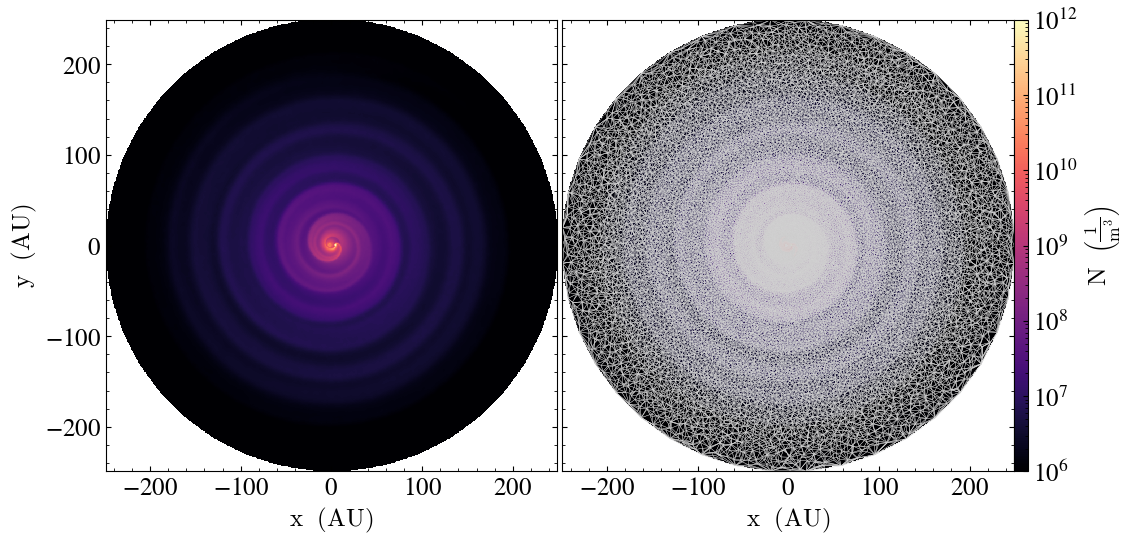

In [8]:
import matplotlib
fig=plt.figure()
grid = AxesGrid(fig, (0.100,0.075,0.85,0.85),
# grid = AxesGrid(fig, (0.100,-0.30,0.825,1.9),
                nrows_ncols = (1, 2),
                axes_pad = 0.05,
                label_mode = "L",
                share_all = True,
                cbar_location="right",
                cbar_mode="single",
                cbar_size="3%",
                cbar_pad="0%")


sl = yt.SlicePlot (ds, 'z', [('connect1', 'n')])
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.set_zlim(('connect1', 'n'), zmin=(1e+6, 'm**(-3)'), zmax=(1e+12, 'm**(-3)'))
sl.zoom(1.1)

plot = sl.plots[('connect1', 'n')]
plot.figure = fig
plot.axes = grid[0].axes
plot.cax = grid.cbar_axes[0]

# Finally, this actually redraws the plot.
sl.render()

sl = yt.SlicePlot (ds, 'z', [('connect1', 'n')])
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (1.1)
sl.set_zlim(('connect1', 'n'), zmin=(1e+6, 'm**(-3)'), zmax=(1e+12, 'm**(-3)'))
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})

plot = sl.plots[('connect1', 'n')]
plot.figure = fig
plot.axes = grid[1].axes
plot.cax = grid.cbar_axes[1]

# Finally, this actually redraws the plot.
sl.render()

plt.savefig("wind_model_density_mesh_original.jpg", dpi = 500, bbox_inches='tight')

The mesh can also be shown seperately


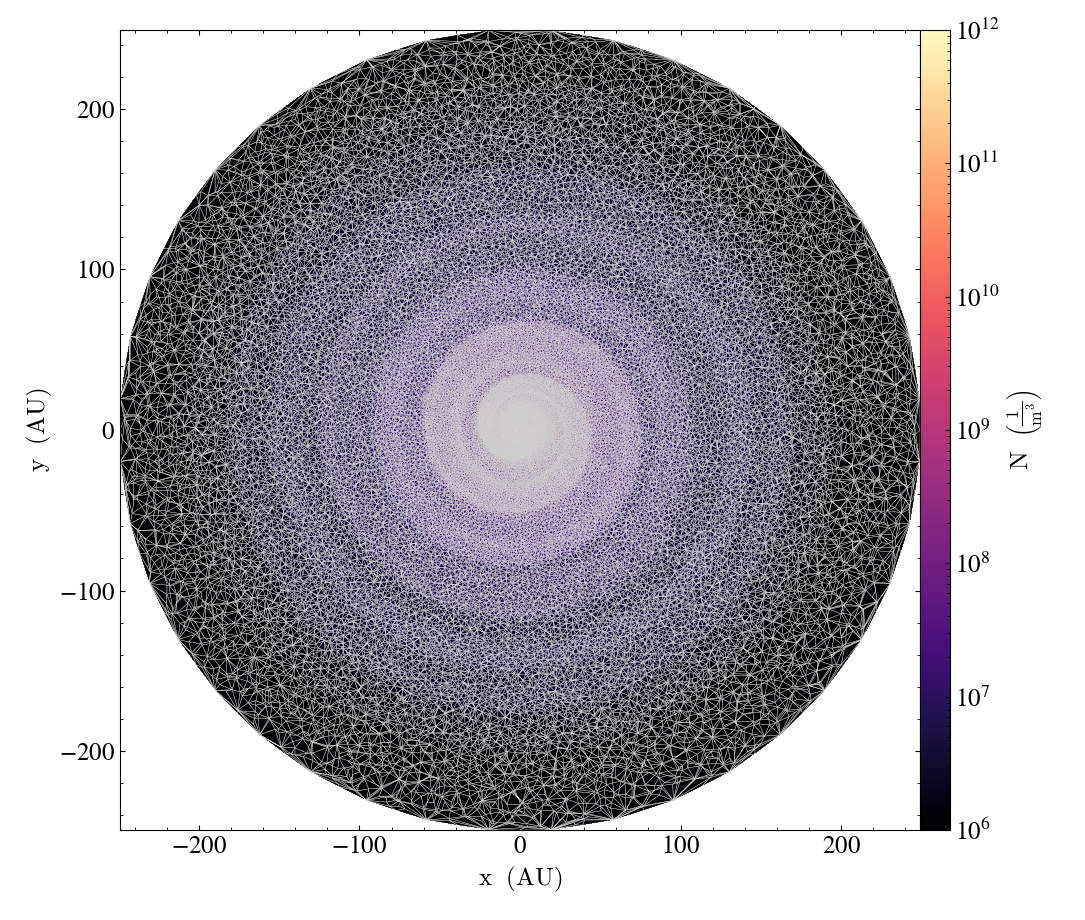

In [9]:
sl = yt.SlicePlot      (ds, 'z', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (1.1)
sl.set_zlim(('connect1', 'n'), zmin=(1e+6, 'm**(-3)'), zmax=(1e+12, 'm**(-3)'))
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})

# Reducing the model (in two different ways)

In [10]:
import magritte.setup  as setup                        # Model setup
import magritte.core   as magritte                     # Core functionality
import magritte.mesher as mesher                       # Mesher
import numpy           as np                           # Data structures
import warnings                                        # Hide warnings
warnings.filterwarnings('ignore')                      # especially for yt
import yt                                              # 3D plotting
import os
import time                                            # For timing

from tqdm                   import tqdm                # Progress bars
from astropy                import constants           # Unit conversions
from scipy.spatial          import Delaunay, cKDTree   # Finding neighbors
from yt.funcs               import mylog               # To avoid yt output 
mylog.setLevel(40)                                     # as error messages
from magritte.haar import Haar

First, we reduce using the old approach (using gmsh)

In [11]:
model_file = os.path.join(wdir, 'model_Phantom_3D_for_comoving.hdf5')   # Original Magritte model
lamda_file = os.path.join(wdir, 'co.txt'               )   # Line data file
redux_file = os.path.join(wdir, 'wind_red' )   # Reduced Magritte model (no extension, as this will be split into 2 different possibilities!)

print(redux_file)

/STER/thomasc/Magritte_comoving_adaptiverays/Magritte-examples/Phantom_3D_more_refinement/wind_red


In [12]:
model = magritte.Model(model_file)

                                           
-------------------------------------------
  Reading Model...                         
-------------------------------------------
 model file = /STER/thomasc/Magritte_comoving_adaptiverays/Magritte-examples/Phantom_3D_more_refinement/model_Phantom_3D_for_comoving.hdf5
-------------------------------------------
Reading parameters...
Reading points...


Reading rays...


Reading boundary...


Reading chemistry...
Reading species...


Reading thermodynamics...
Reading temperature...
Reading turbulence...
Reading lines...


Reading lineProducingSpecies...
Reading linedata...
read num 0
read sym CO
nlev = 41
nrad = 40
Reading collisionPartner...


Reading collisionPartner...


Reading quadrature...


Reading radiation...
Reading frequencies...


Not using scattering!
                                           
-------------------------------------------
  Model read, parameters:                  
-------------------------------------------
  npoints    = 885501
  nrays      = 72
  nboundary  = 1200
  nfreqs     = 840
  nspecs     = 3
  nlspecs    = 1
  nlines     = 40
  nquads     = 21
-------------------------------------------
                                           


Use the recursive mesher (and add a spherical boundary at 0.99 max radius)

In [13]:
start = time.time()
radius = 0.99*np.max(np.linalg.norm(position, axis=1))
rec_points, nb_boundary_rec = mesher.remesh_point_cloud(position, nCO, max_depth = 12, threshold = 4e-1, hullorder = 3)
rec_points, nb_boundary_rec = mesher.point_cloud_add_spherical_outer_boundary(rec_points, nb_boundary_rec, radius)
end = time.time()
print("recursive remeshing time: ", end-start)


new interior points:  51368
number boundary points:  386
recursive remeshing time:  2.2880804538726807


Compare the points in the original and reduced meshes; parameters were chosen such that the reduced grids have approximately the same number of points as the original ones.

In [14]:
npoints          = model.parameters.npoints()
npoints_reduced_rec  = len(rec_points)

print('npoints original =', npoints)
print('npoints reduced rec =', npoints_reduced_rec)
print('reduction factor rec =', npoints/npoints_reduced_rec)


npoints original = 885501
npoints reduced rec = 52258
reduction factor rec = 16.944793141719927


Save all models

In [15]:
corresp_points_rec = cKDTree(position).query(rec_points)[1]
#map data for recursive remesh (nearest neighbor interpolation)

position_reduced_rec = rec_points#position[corresp_points_rec]
velocity_reduced_rec = velocity[corresp_points_rec]
nCO_reduced_rec      = nCO     [corresp_points_rec]
nH2_reduced_rec      = nH2     [corresp_points_rec]
tmp_reduced_rec      = tmp     [corresp_points_rec]
trb_reduced_rec      = trb     [corresp_points_rec]

# Extract Delaunay vertices (= Voronoi neighbors)
delaunay_rec = Delaunay(position_reduced_rec)
(indptr, indices) = delaunay_rec.vertex_neighbor_vertices
neighbors_rec = [indices[indptr[k]:indptr[k+1]] for k in range(npoints_reduced_rec)]
nbs_rec       = [n for sublist in neighbors_rec for n in sublist]
n_nbs_rec     = [len(sublist) for sublist in neighbors_rec]

# Convenience arrays
zeros_rec = np.zeros(npoints_reduced_rec)
ones_rec  = np.ones (npoints_reduced_rec)

Write recursive model

In [16]:
NLINES = 40
NQUADS = 21
model = magritte.Model ()                                        # Create model object

model.parameters.set_model_name         (f'{redux_file}_rec.hdf5')   # Magritte model file
model.parameters.set_dimension          (3)                      # This is a 3D model
model.parameters.set_npoints            (npoints_reduced_rec)        # Number of points
# model.parameters.set_nrays              (12*8**2)                      # Number of rays  
# model.parameters.set_hnrays             (6*8**2)                      # Number of rays  
model.parameters.set_nspecs             (5)                      # Number of species (min. 5)
model.parameters.set_nlspecs            (1)                      # Number of line species
model.parameters.set_nfreqs             (NQUADS*NLINES)
model.parameters.set_nlines             (NLINES)
model.parameters.set_nquads             (NQUADS)                     # Number of quadrature points

model.geometry.points.position.set(position_reduced_rec)
model.geometry.points.velocity.set(velocity_reduced_rec)

model.geometry.points.  neighbors.set(  nbs_rec)
model.geometry.points.n_neighbors.set(n_nbs_rec)

model.chemistry.species.abundance = np.array((zeros_rec, nCO_reduced_rec, nH2_reduced_rec, zeros_rec, ones_rec)).T
model.chemistry.species.symbol    = ['dummy0', 'CO', 'H2', 'e-', 'dummy1']

model.thermodynamics.temperature.gas  .set(tmp_reduced_rec)
model.thermodynamics.turbulence.vturb2.set(trb_reduced_rec)

#recursive remeshing results in the first nb_boundary points being the boundary points
model.parameters.set_nboundary(nb_boundary_rec)
model.geometry.boundary.boundary2point.set(np.arange(nb_boundary_rec))

# direction = np.array([[0,0,+1], [0,0,-1]])            # Comment out to use all directions
# model.geometry.rays.direction.set(direction)          # Comment out to use all directions
# model.geometry.rays.weight   .set(0.5 * np.ones(2))   # Comment out to use all directions

# model = setup.set_uniform_rays            (model)   # Uncomment to use all directions
model = setup.set_adaptive_rays           (model, Ncomparisons=10000, Nrefiments=5)
model = setup.set_boundary_condition_CMB  (model)
model = setup.set_linedata_from_LAMDA_file(model, lamda_file, {'considered transitions': [i for i in range(NLINES)]})
# model = setup.set_linedata_from_LAMDA_file(model, lamda_file)   # Consider all transitions
model = setup.set_quadrature              (model)
# model = setup.set_quadrature_equidistant  (model, 5.0)#test out equidistant quadrature, in order to keep maximal amount of information

model.write()

Computing adaptive rays for points:
0
1000
2000
3000
4000
5000
7000
6000
8000
10000
11000
9000
12000
13000
15000
16000
14000
17000
18000
19000
20000
21000
23000
22000
24000
25000
26000
27000
29000
28000
30000
31000


32000


33000


35000
34000
36000
37000


38000
39000
40000
41000
42000


...

Writing boundary...
Writing chemistry...
Writing species...


Writing thermodynamics...
Writing temperature...
Writing turbulence...
Writing lines...
Writing lineProducingSpecies...
Writing linedata...


ncolpoar = 2
--- colpoar = 0
Writing collisionPartner...
(l, c) = 0, 0


--- colpoar = 1
Writing collisionPartner...
(l, c) = 0, 1


Writing quadrature...
Writing populations...
Writing radiation...
Writing frequencies...


## Plotting the recursive remesh

In [17]:
model_rec = magritte.Model(f'{redux_file}_rec.hdf5')
position_reduced_rec = np.array(model_rec.geometry.points.position)

                                           
-------------------------------------------
  Reading Model...                         
-------------------------------------------
 model file = /STER/thomasc/Magritte_comoving_adaptiverays/Magritte-examples/Phantom_3D_more_refinement/wind_red_rec.hdf5
-------------------------------------------
Reading parameters...
Reading points...


Reading rays...


Reading boundary...
Reading chemistry...
Reading species...
Reading thermodynamics...
Reading temperature...
Reading turbulence...
Reading lines...
Reading lineProducingSpecies...
Reading linedata...
read num 1
read sym CO
nlev = 41
nrad = 40


Reading collisionPartner...


Reading collisionPartner...


Reading quadrature...
Reading radiation...


Reading frequencies...
Not using scattering!
                                           
-------------------------------------------
  Model read, parameters:                  
-------------------------------------------
  npoints    = 52258
  nrays      = 72
  nboundary  = 1202
  nfreqs     = 840
  nspecs     = 5
  nlspecs    = 1
  nlines     = 40
  nquads     = 21
-------------------------------------------
                                           


In [18]:
from scipy.spatial import Delaunay
delaunay_rec = Delaunay(position_reduced_rec)
nCO_reduced_rec = np.array(model_rec.chemistry.species.abundance)[:,1]
ds_rec = yt.load_unstructured_mesh(
         connectivity = delaunay_rec.simplices.astype(np.int64),
         coordinates  = delaunay_rec.points.astype(np.float64) * 100.0, # yt expects cm not m
         node_data    = {('connect1', 'n'): nCO_reduced_rec[delaunay_rec.simplices].astype(np.float64)/ yt.units.m**3}
)

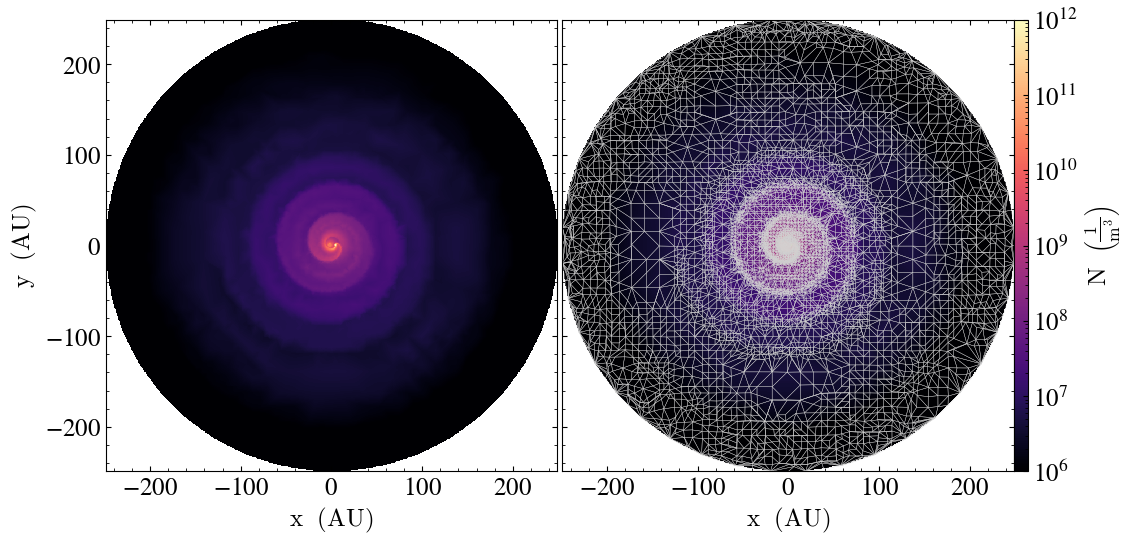

In [19]:
fig=plt.figure()
grid = AxesGrid(fig, (0.075,0.075,0.85,0.85),
                nrows_ncols = (1, 2),
                axes_pad = 0.05,
                label_mode = "L",
                share_all = True,
                cbar_location="right",
                cbar_mode="single",
                cbar_size="3%",
                cbar_pad="0%")

sl = yt.SlicePlot (ds_rec, 'z', ('connect1', 'n'))
sl.set_cmap       (('connect1', 'n'), 'magma')
sl.set_zlim(('connect1', 'n'), zmin=(1e+6, 'm**(-3)'), zmax=(1e+12, 'm**(-3)'))
sl.zoom           (1.1)

plot = sl.plots[('connect1', 'n')]
plot.figure = fig
plot.axes = grid[0].axes
plot.cax = grid.cbar_axes[0]

# Finally, this actually redraws the plot.
sl.render()

sl = yt.SlicePlot      (ds_rec, 'z', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (1.1)
sl.set_zlim(('connect1', 'n'), zmin=(1e+6, 'm**(-3)'), zmax=(1e+12, 'm**(-3)'))
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})


plot = sl.plots[('connect1', 'n')]
plot.figure = fig
plot.axes = grid[1].axes
plot.cax = grid.cbar_axes[1]

# # Finally, this actually redraws the plot.
sl.render()
plt.savefig("wind_model_density_mesh_rec.jpg", dpi = 500, bbox_inches='tight')


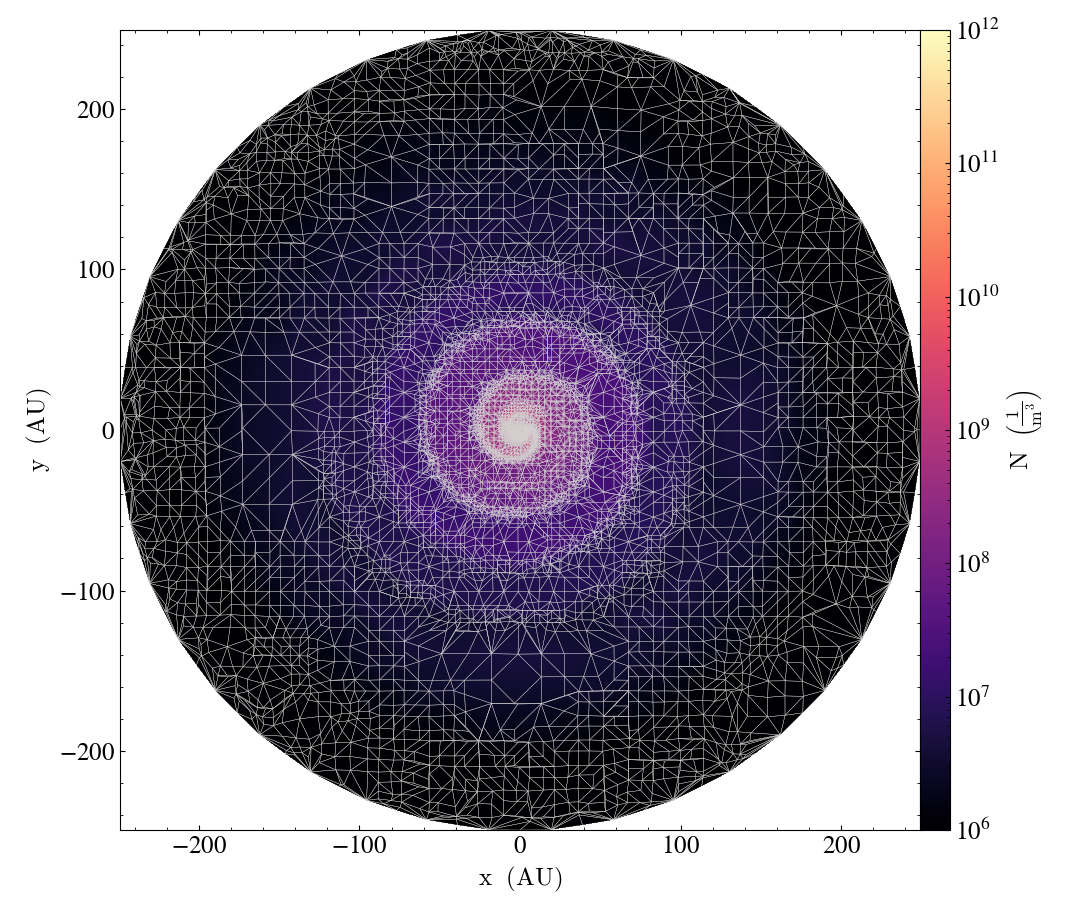

In [20]:
sl = yt.SlicePlot      (ds_rec, 'z', ('connect1', 'n'))
sl.set_cmap            (('connect1', 'n'), 'magma')
sl.zoom                (1.1)
sl.set_zlim(('connect1', 'n'), zmin=(1e+6, 'm**(-3)'), zmax=(1e+12, 'm**(-3)'))
sl.annotate_mesh_lines (plot_args={'color':'lightgrey', 'linewidths':[.25]})